In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


In [4]:
image_cut = image[55:155, 0:1800]
image_error_cut = image_error[55:155, 0:1800]

In [5]:
image_error_cut

array([[0.0303987 , 0.02912354, 0.02480921, ..., 0.0067154 , 0.00691563,
        0.00693766],
       [0.03006888, 0.02813161, 0.02885036, ..., 0.00677515, 0.0061732 ,
        0.00663774],
       [0.03166641, 0.02917927, 0.03076373, ..., 0.00689471, 0.00661363,
        0.00693721],
       ...,
       [0.02708479, 0.02681352, 0.03034172, ..., 0.00661501, 0.00649011,
        0.00683801],
       [0.02696249, 0.02753854, 0.02932177, ..., 0.00645496, 0.00637915,
        0.00649103],
       [0.02817379, 0.02815345, 0.02910345, ..., 0.00675251, 0.00685232,
        0.00682028]], dtype='>f4')

Text(0.5, 0, 'wavelenght')

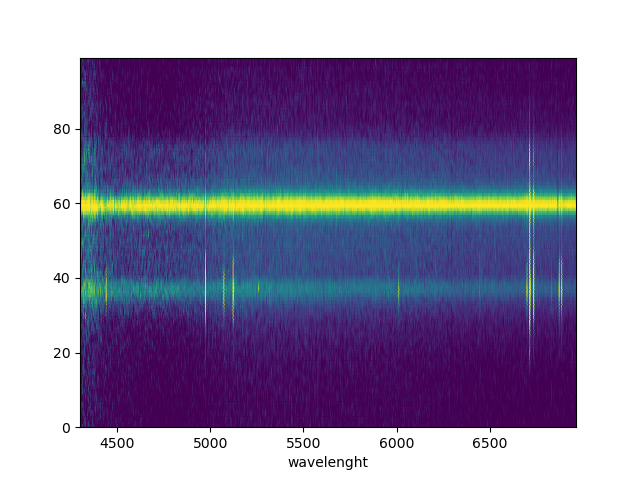

In [6]:
wavelenghts = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelenghts, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

## Redshift or the lines in air

In [7]:
z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

In [8]:
l_HA

6719.1994

## Continuum

Text(0.5, 1.0, 'Continuum 3')

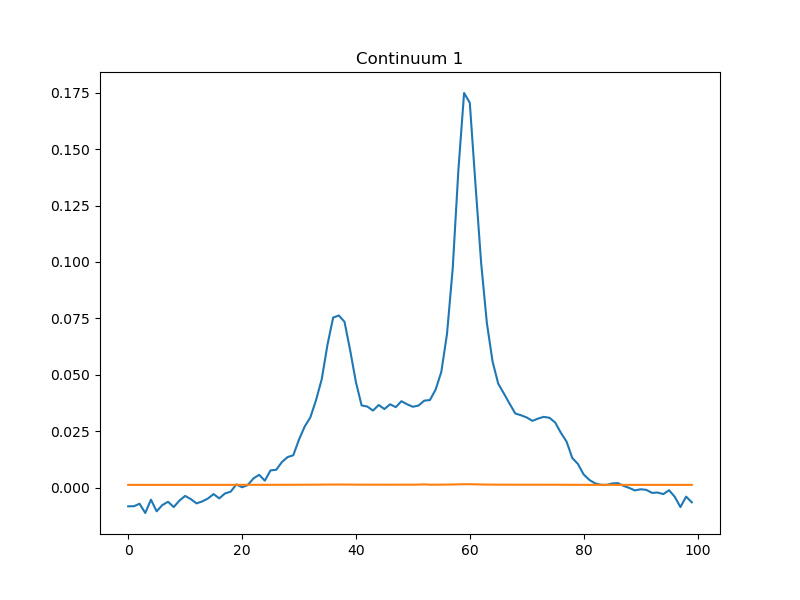

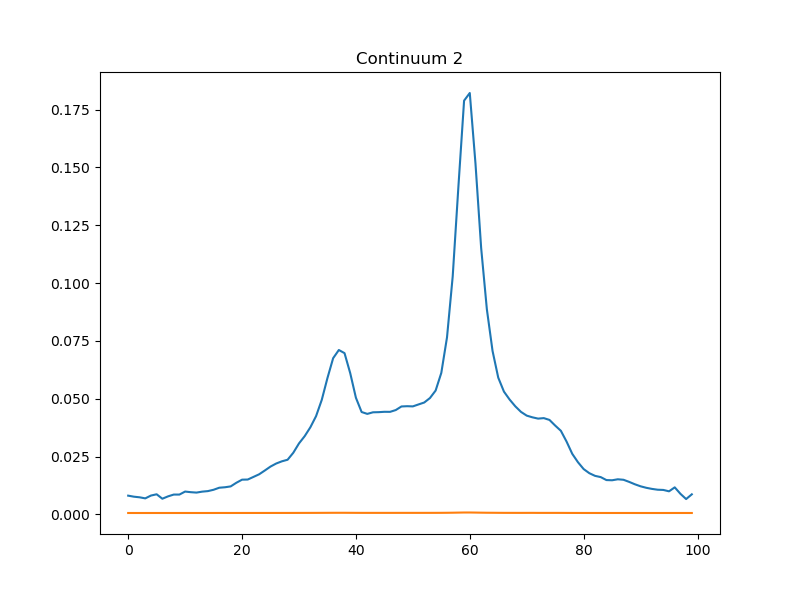

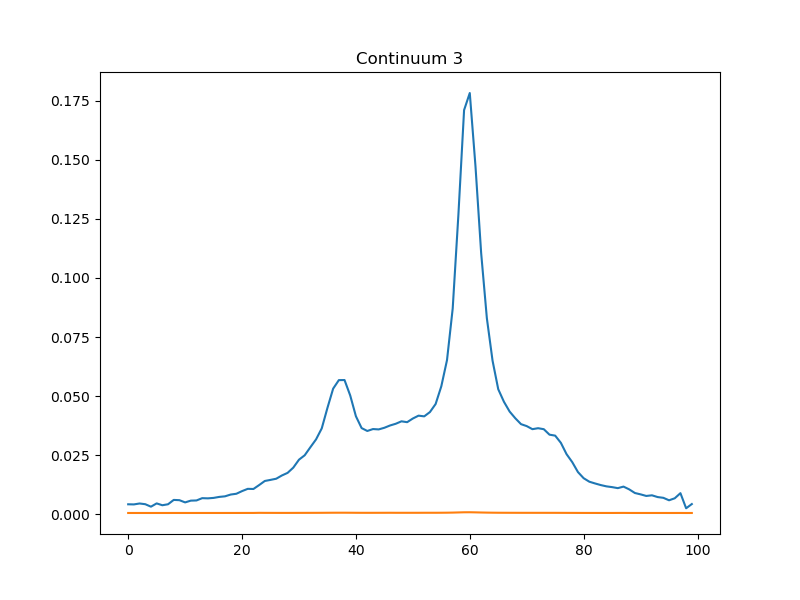

In [19]:
mask_continuum_1 = (wavelenghts > 4500)*(wavelenghts < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.mean(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))/image_error_continuum_1.shape[1]

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

mask_continuum_2 = (wavelenghts > 5300)*(wavelenghts < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.mean(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))/image_error_continuum_2.shape[1]

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

mask_continuum_3 = (wavelenghts > 6400)*(wavelenghts < 6700)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.mean(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))/image_error_continuum_3.shape[1]

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

## Sky lines

In [51]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[55:155, 0:1800]

x_grid, y_grid = np.meshgrid(wavelenghts, y)
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


Text(0.5, 45.40277777777776, 'wavelenght')

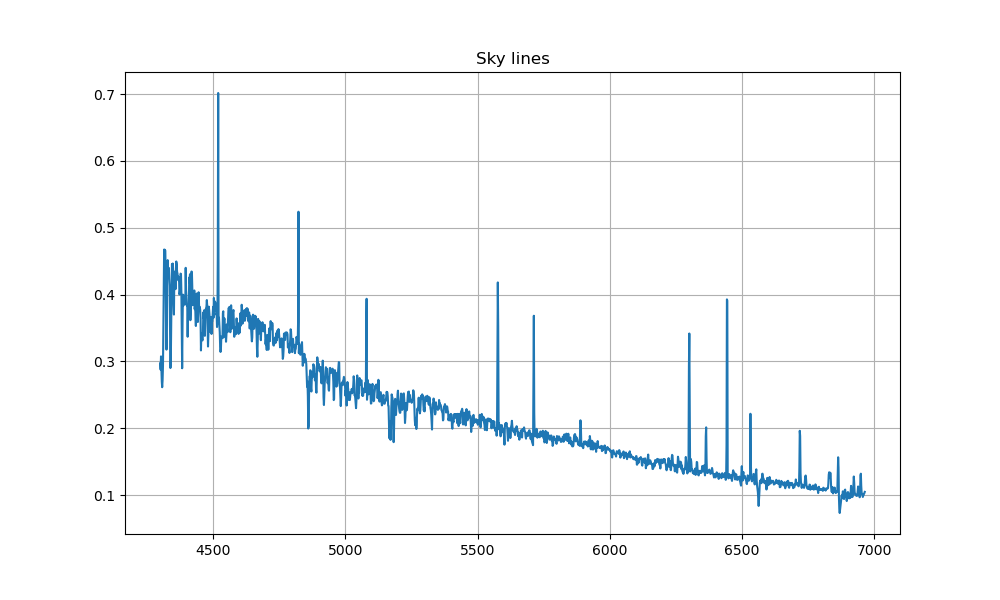

In [61]:
mask_sky = (y > 15)*(y < 25)
image_sky = image_cut2[mask_sky, :]
radial_profile_sky = np.mean(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wavelenghts, radial_profile_sky)
#x_interval = np.arange(4300, 4300+1800*1.48, 250)
#plt.xticks(x_interval)
plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

[0.00199995 0.00200032 0.00201779 0.00201654 0.00201868 0.00203275
 0.00201366 0.0020099  0.00203024 0.00205202 0.00203898 0.00203963
 0.0020376  0.00202088 0.00204492 0.00207772 0.00209198 0.00213538
 0.00217228 0.00222195 0.00228526 0.00227263 0.00223645 0.00223431
 0.00227714 0.00233891 0.00243793 0.0025702  0.00272596 0.00295238
 0.00321087 0.0034536  0.00376587 0.00418121 0.00487717 0.00576524
 0.00630024 0.00602531 0.00534679 0.00486246 0.00457629 0.00432444
 0.00415814 0.00401824 0.00374189 0.00338401 0.00306796 0.0028266
 0.00268036 0.00262352 0.00260347 0.00260557 0.00261961 0.00266591
 0.00274526 0.00279248 0.00288641 0.00317191 0.00381031 0.00446422
 0.00446514 0.00390629 0.00329925 0.0029124  0.00273268 0.00260608
 0.00251682 0.00248584 0.00246874 0.00246579 0.00251553 0.00255168
 0.00257687 0.0025161  0.00246694 0.00242411 0.0023613  0.00230715
 0.00224925 0.00217891 0.00216434 0.00215001 0.00212812 0.00213713
 0.00213505 0.00209866 0.00210264 0.00207148 0.00208502 0.00206

Text(0.5, 1.0, 'H$\\alpha$')

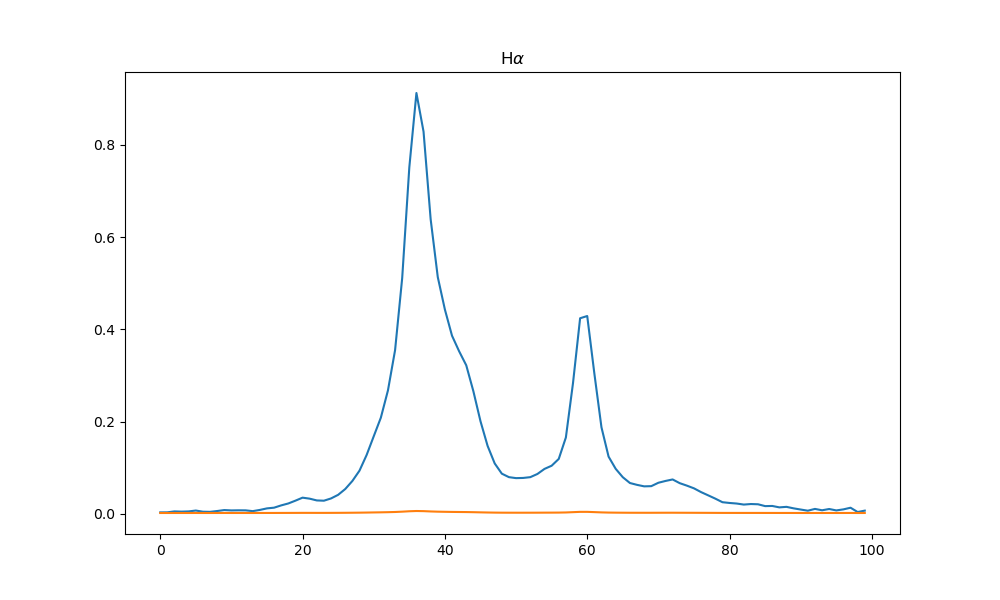

In [9]:
#Ogni punto del flusso è il risultato della media di 20 lunghezze d'onda, otteniamo l'errore come std della media
mask_HA = (wavelenghts > l_HA-10)*(wavelenghts < l_HA+10)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.mean(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))/image_error_HA.shape[1]
print(radial_profile_error_HA)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [23]:
np.sqrt(np.sum(image_error_HA[0]**2))/len(image_error_HA[0])
image_error_HA.shape[1]

13

In [24]:
image_error_HA[:, 7]

array([0.00719964, 0.00716636, 0.00713236, 0.00721354, 0.00737467,
       0.00749214, 0.0075564 , 0.00730903, 0.00728604, 0.00769035,
       0.00758607, 0.00747766, 0.00744139, 0.00739624, 0.00749539,
       0.0077408 , 0.00786305, 0.00766336, 0.00761351, 0.00779215,
       0.00789512, 0.00802868, 0.0082304 , 0.00853798, 0.00883493,
       0.00907985, 0.00946892, 0.01010476, 0.01071307, 0.01151189,
       0.01300277, 0.01381353, 0.0147665 , 0.01698969, 0.0206352 ,
       0.02544307, 0.02793511, 0.02587998, 0.02216176, 0.02009732,
       0.01946655, 0.01849345, 0.01779391, 0.01720328, 0.01595465,
       0.01417364, 0.01242753, 0.01135235, 0.0105706 , 0.01016033,
       0.0100691 , 0.01018346, 0.01000953, 0.01022657, 0.01087661,
       0.01123802, 0.01182259, 0.01355989, 0.01698731, 0.02066084,
       0.02059019, 0.01726205, 0.01386188, 0.01178729, 0.01118319,
       0.010574  , 0.00994297, 0.00939923, 0.009142  , 0.00897904,
       0.00946809, 0.00920493, 0.00938193, 0.0092591 , 0.00890

In [25]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 40),   # x_0: posizione da 0 a 100

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (40, 50),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (50, 70),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (70, 80)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 2.797210359638261
differential_evolution step 2: f(x)= 2.4762738819003123
differential_evolution step 3: f(x)= 1.9658331556797455
differential_evolution step 4: f(x)= 1.5775640793830688
differential_evolution step 5: f(x)= 1.4856539760708343
differential_evolution step 6: f(x)= 0.9576938266899773
differential_evolution step 7: f(x)= 0.6899004371436728
differential_evolution step 8: f(x)= 0.6899004371436728
differential_evolution step 9: f(x)= 0.6633438762716755
differential_evolution step 10: f(x)= 0.5919225793343276
differential_evolution step 11: f(x)= 0.5919225793343276
differential_evolution step 12: f(x)= 0.5919225793343276
differential_evolution step 13: f(x)= 0.5873647258662547
differential_evolution step 14: f(x)= 0.4713018605622866
differential_evolution step 15: f(x)= 0.4697296335123365
differential_evolution step 16: f(x)= 0.4584709226088419
differential_evolution step 17: f(x)= 0.4584709226088419
differential_evolution step 18: f(x)= 0.4

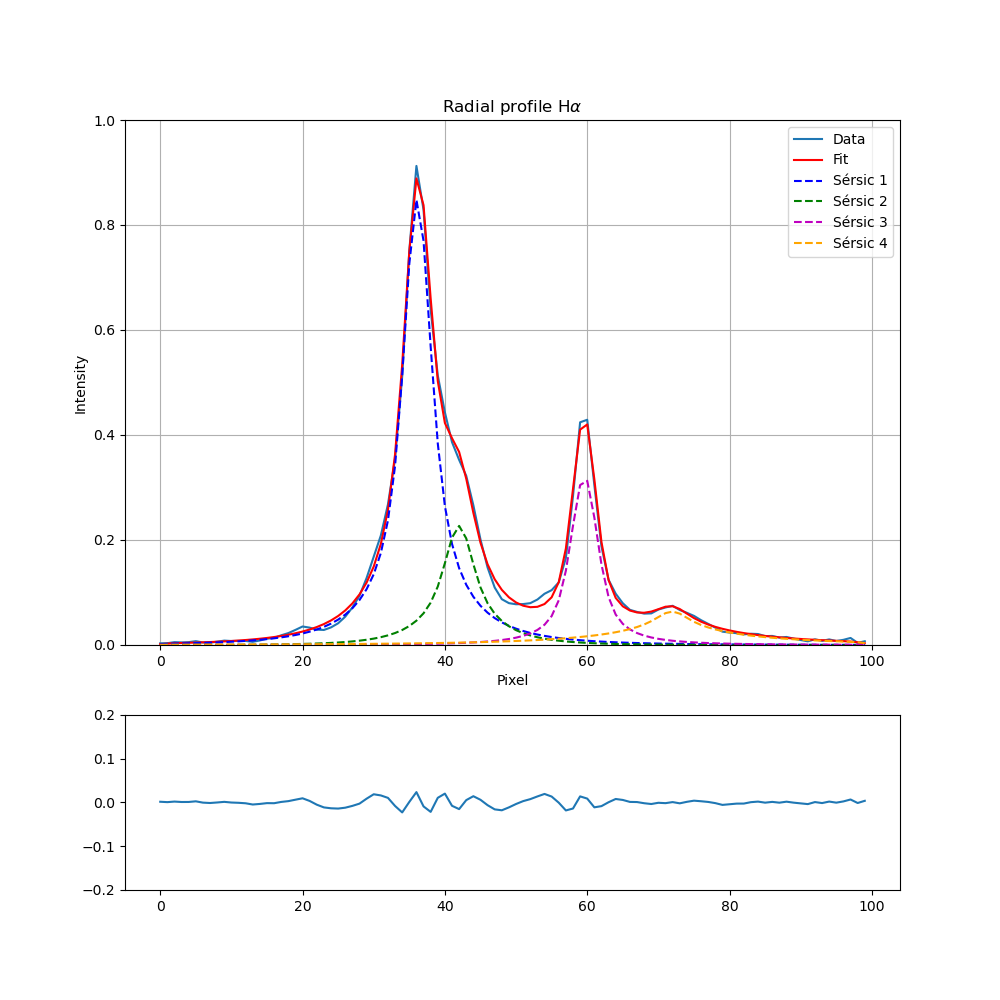

In [26]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
ax[1].set_ylim(-0.2, 0.2)

plt.savefig('Radial_profile_Halpha_diff')

In [27]:
params_curve_HA, covariance_HA = curve_fit(model_convolved, x_axes, radial_profile_HA, p0=result.x, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0_HA = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0_HA[i] = params_curve_HA[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_HA)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_HA)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_HA)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_HA)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0_HA[i]:.4f}")

print(np.sqrt(np.diag(covariance_HA)))
#print(infodict.fvec**2)
chi2_HA = np.sum((((radial_profile_HA - model_convolved(x_axes, *params_curve_HA)) / radial_profile_error_HA)**2))
dof_HA = len(radial_profile_HA) - len(params_curve_HA)
chi2_reduced_HA = chi2_HA / dof_HA
print(chi2_reduced_HA)

d1 = {'Component': [1, 2, 3, 4], 'I_e': I_e , 'I_e error': I_e_err, 'r_e': r_e, 'r_e error': r_e_err, 'n': n, 'n error': n_err, 'x_0': x_0_HA, 'x_0 err': x_0_err}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Halpha_fit.csv", index= False, float_format='%.4f')

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_7096\621409132.py:11: RuntimeWarning:

invalid value encountered in power

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_7096\621409132.py:22: RuntimeWarning:

Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.



Optimize parameters with curve fit:
Sérsic 1: I_e=0.0701, r_e=8.9665, n=1.8486, x_0=36.1981
Sérsic 2: I_e=0.0282, r_e=6.4398, n=1.4745, x_0=42.1684
Sérsic 3: I_e=0.0078, r_e=16.0591, n=3.2100, x_0=59.5634
Sérsic 4: I_e=0.0026, r_e=42.6300, n=1.9598, x_0=72.1817
[1.20448117e-02 1.03349310e+00 1.29371984e-01 4.56039547e-02
 2.12523704e-02 4.17361384e+00 5.42172118e-01 1.62683506e-01
 4.56530047e-02 6.53451363e+01 6.08096189e+00 1.48208696e-03
 2.34397511e-03 4.06473653e+01 5.79189118e-01 4.01706507e-01]
7.531249798026085


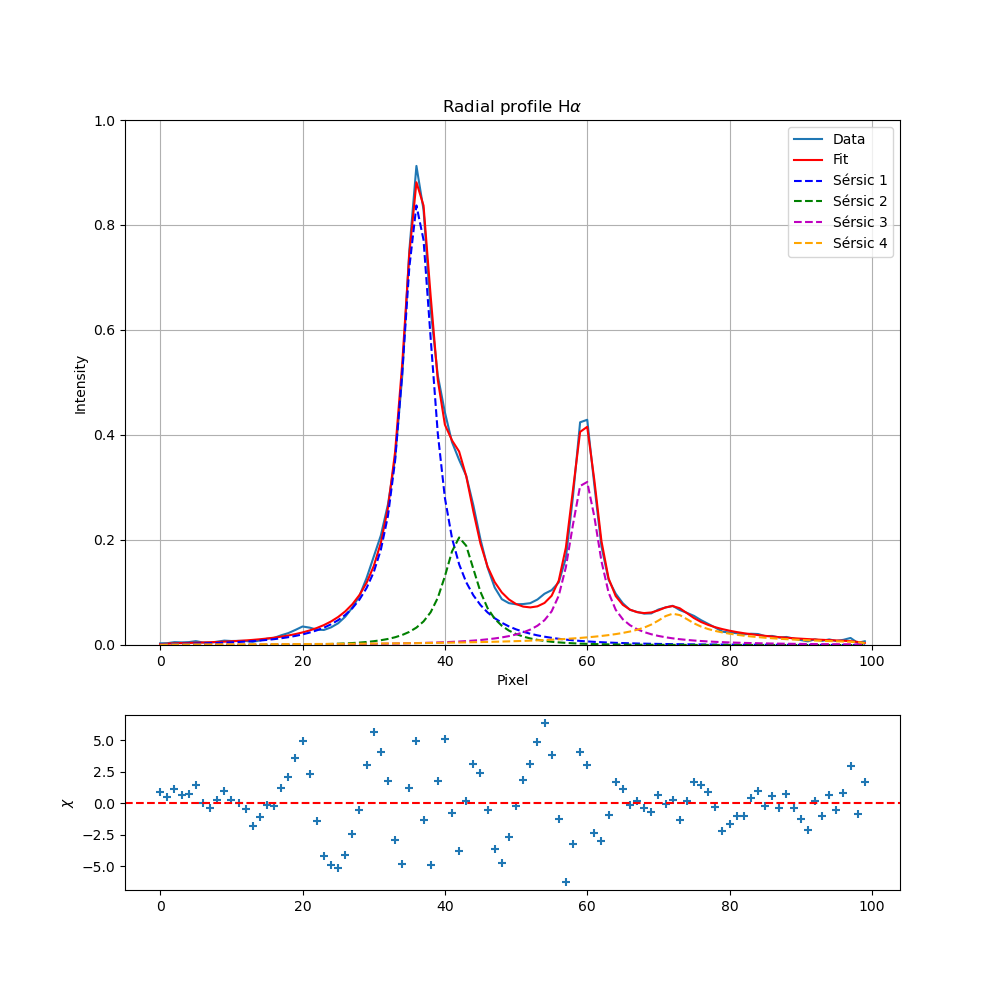

In [75]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_HA)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HA[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HA[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HA[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HA[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)
#ax[0].tight_layout()

ax[1].scatter(x_axes, (radial_profile_HA - y_fit)/radial_profile_error_HA, marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')

plt.savefig('Radial_profile_Halpha_curve')

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

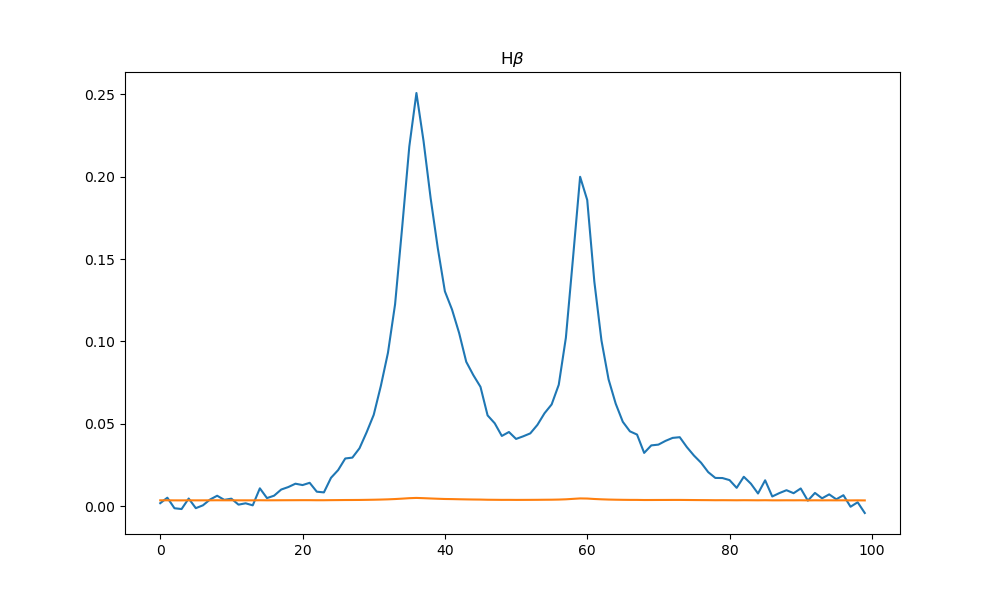

In [10]:
mask_HB = (wavelenghts > l_HB-10)*(wavelenghts < l_HB+10)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.mean(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))/image_error_HB.shape[1]

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [30]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 0.3370353274650254
differential_evolution step 2: f(x)= 0.08785019519577698
differential_evolution step 3: f(x)= 0.04467610513558069
differential_evolution step 4: f(x)= 0.04467610513558069
differential_evolution step 5: f(x)= 0.04467610513558069
differential_evolution step 6: f(x)= 0.04467610513558069
differential_evolution step 7: f(x)= 0.04467610513558069
differential_evolution step 8: f(x)= 0.04467610513558069
differential_evolution step 9: f(x)= 0.04467610513558069
differential_evolution step 10: f(x)= 0.04467610513558069
differential_evolution step 11: f(x)= 0.04467610513558069
differential_evolution step 12: f(x)= 0.04467610513558069
differential_evolution step 13: f(x)= 0.04467610513558069
differential_evolution step 14: f(x)= 0.04467610513558069
differential_evolution step 15: f(x)= 0.04467610513558069
differential_evolution step 16: f(x)= 0.04467610513558069
differential_evolution step 17: f(x)= 0.03877220705045643
differential_evolution s

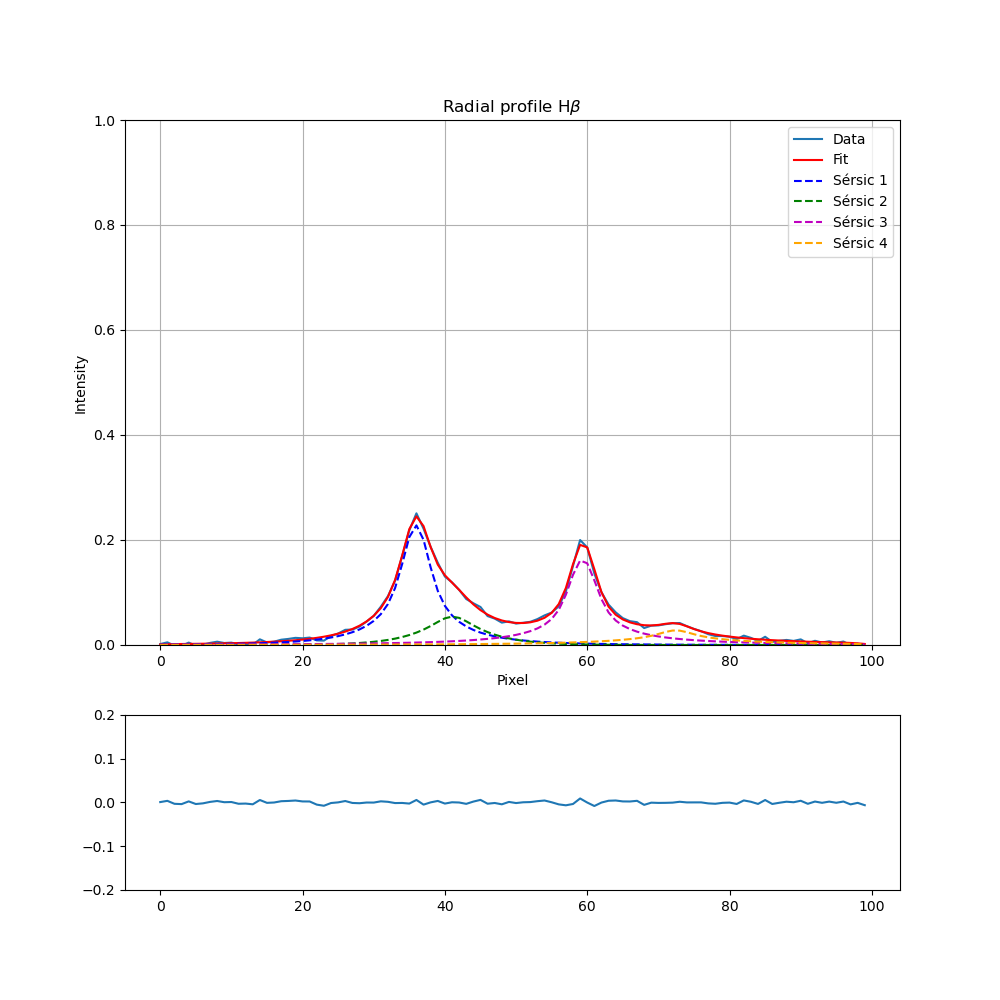

In [31]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_HB, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\beta$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0,1)

ax[1].plot(x_axes, radial_profile_HB - y_fit)
ax[1].set_ylim(-0.2, 0.2)
plt.savefig('Radial_profile_Hbeta_kernel')

In [32]:
params_curve_HB, covariance_HB = curve_fit(model_convolved, x_axes, radial_profile_HB, p0=result.x, sigma = radial_profile_error_HB)

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0 = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_HB[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_HB)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_HB)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_HB)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_HB)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = {'Component': [1, 2, 3, 4], 'I_e': I_e , 'I_e error': I_e_err, 'r_e': r_e, 'r_e error': r_e_err, 'n': n, 'n error': n_err, 'x_0': x_0, 'x_0 err': x_0_err}
df1 = pd.DataFrame(data=d1)
df1.to_csv("HBeta_fit.csv", index= False, float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_HB)))
#print(infodict.fvec**2)
chi2_HB = np.sum((((radial_profile_HB - model_convolved(x_axes, *params_curve_HB)) / radial_profile_error_HB)**2))
dof_HB = len(radial_profile_HB) - len(params_curve_HB)
chi2_reduced_HB = chi2_HB / dof_HB
print(chi2_reduced_HB)

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_7096\4061730068.py:11: RuntimeWarning:

invalid value encountered in power

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_7096\4061730068.py:22: RuntimeWarning:

Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.



Sérsic 1: I_e=0.0178, r_e=10.4787, n=1.7913, x_0=35.9238
Sérsic 2: I_e=0.0137, r_e=7.2631, n=0.9336, x_0=41.0874
Sérsic 3: I_e=0.0035, r_e=27.7747, n=2.9013, x_0=59.3901
Sérsic 4: I_e=0.0018, r_e=27.5169, n=1.7449, x_0=72.4608
[6.89627593e-03 2.99805743e+00 2.55744130e-01 7.93819094e-02
 6.48526231e-03 2.55313064e+00 2.97593385e-01 6.05762000e-01
 8.97100788e-03 5.65027857e+01 2.22011057e+00 1.46780163e-03
 1.96608929e-03 3.76935927e+01 7.34241657e-01 3.76898880e-01]
0.8195013913846726


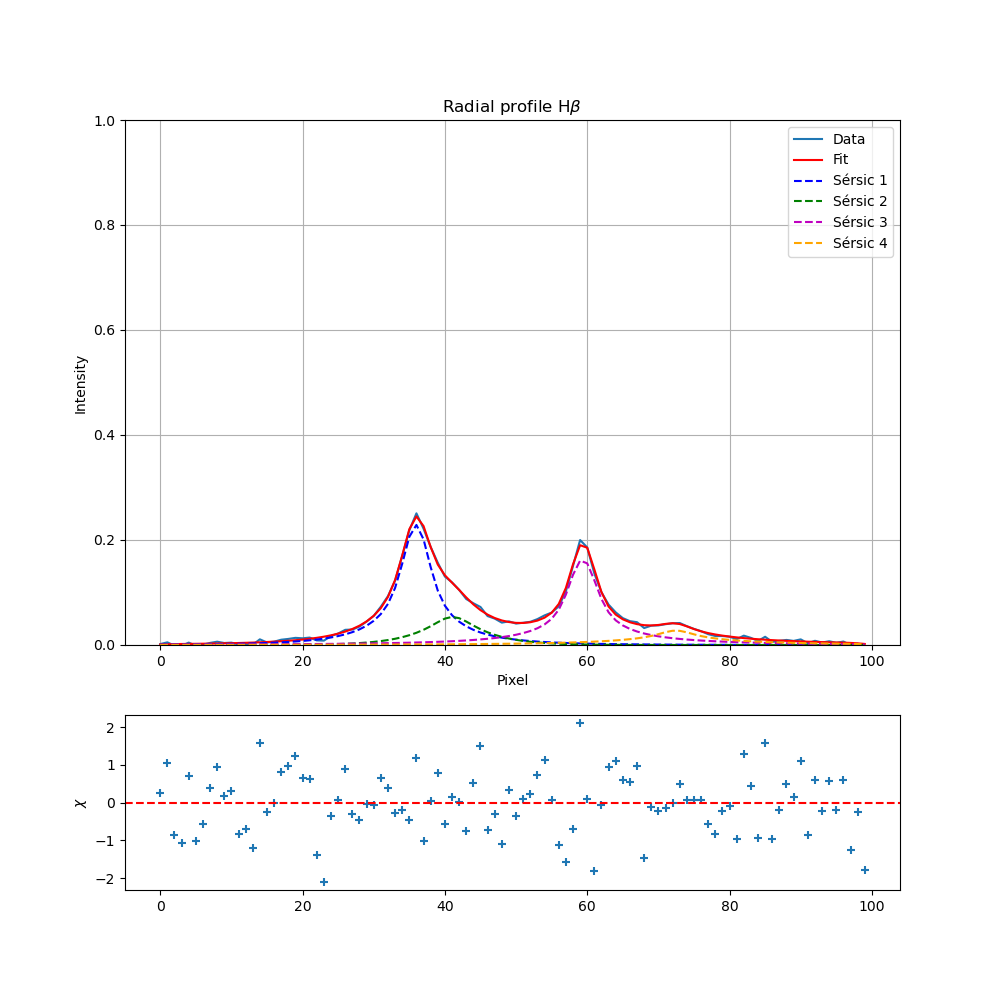

In [74]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_HB)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_HB, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HB[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HB[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HB[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HB[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\beta$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)

ax[1].scatter(x_axes, (radial_profile_HB - y_fit)/radial_profile_error_HB, marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

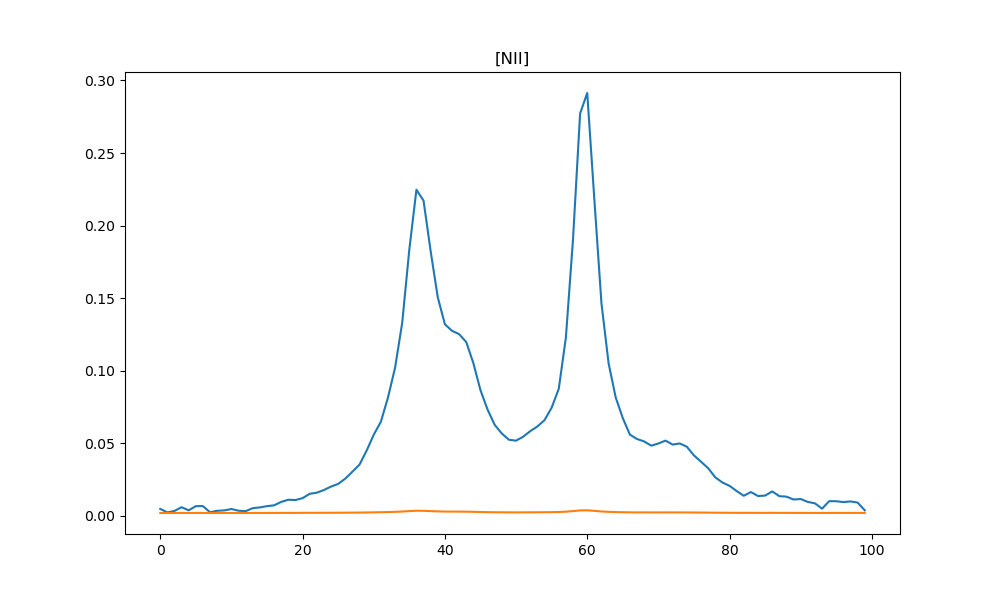

In [77]:
mask_NII = (wavelenghts > l_NII-10)*(wavelenghts < l_NII+10)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.mean(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))/image_error_NII.shape[1]
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [35]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 2.825827701351056
differential_evolution step 2: f(x)= 0.3545815492626701
differential_evolution step 3: f(x)= 0.3545815492626701
differential_evolution step 4: f(x)= 0.12548435179004255
differential_evolution step 5: f(x)= 0.12548435179004255
differential_evolution step 6: f(x)= 0.12548435179004255
differential_evolution step 7: f(x)= 0.12548435179004255
differential_evolution step 8: f(x)= 0.12548435179004255
differential_evolution step 9: f(x)= 0.12548435179004255
differential_evolution step 10: f(x)= 0.12548435179004255
differential_evolution step 11: f(x)= 0.0612927236289854
differential_evolution step 12: f(x)= 0.0612927236289854
differential_evolution step 13: f(x)= 0.0612927236289854
differential_evolution step 14: f(x)= 0.0612927236289854
differential_evolution step 15: f(x)= 0.0612927236289854
differential_evolution step 16: f(x)= 0.0612927236289854
differential_evolution step 17: f(x)= 0.0612927236289854
differential_evolution step 18: f(

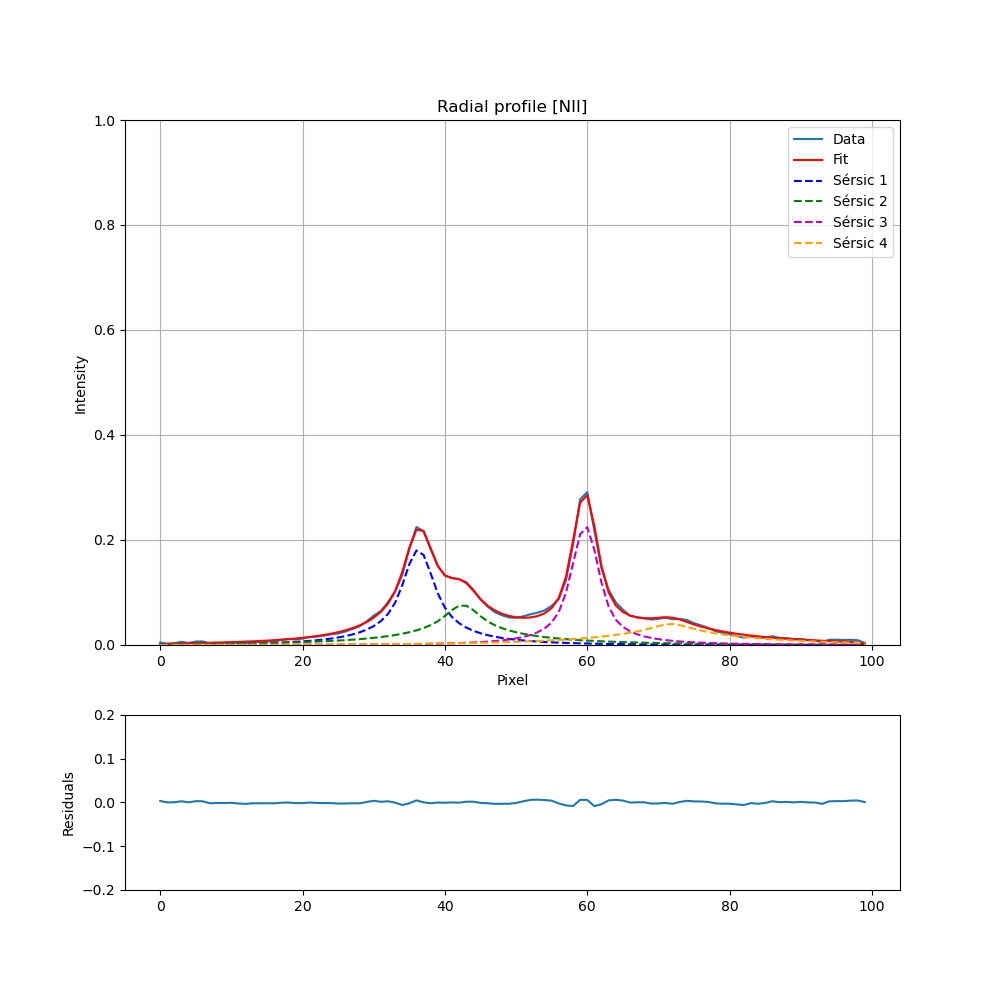

In [36]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_NII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [NII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)

ax[1].plot(x_axes, radial_profile_NII - y_fit)
ax[1].set_ylim(-0.2, 0.2)
ax[1].set_ylabel('Residuals')
plt.savefig('Radial_profile_NII_kernel')

In [37]:
params_curve_NII, covariance_NII = curve_fit(model_convolved, x_axes, radial_profile_NII, p0=result.x, sigma = radial_profile_error_NII)

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0 = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_NII[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_NII)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_NII)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_NII)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_NII)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = {'Component': [1, 2, 3, 4], 'I_e': I_e , 'I_e error': I_e_err, 'r_e': r_e, 'r_e error': r_e_err, 'n': n, 'n error': n_err, 'x_0': x_0, 'x_0 err': x_0_err}
df1 = pd.DataFrame(data=d1)
df1.to_csv("NII_fit.csv", index= False, float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_NII)))
#print(infodict.fvec**2)
chi2_NII = np.sum((((radial_profile_NII - model_convolved(x_axes, *params_curve_NII)) / radial_profile_error_NII)**2))
dof_NII = len(radial_profile_NII) - len(params_curve_NII)
chi2_reduced_NII = chi2_NII / dof_NII
print(chi2_reduced_NII)

Sérsic 1: I_e=0.0141, r_e=11.3285, n=1.8814, x_0=36.3295
Sérsic 2: I_e=0.0049, r_e=19.8288, n=1.8035, x_0=42.5685
Sérsic 3: I_e=0.0063, r_e=16.3916, n=2.9278, x_0=59.6624
Sérsic 4: I_e=0.0028, r_e=36.1991, n=1.6134, x_0=72.2259
[6.50631617e-03 5.01517101e+00 3.22024913e-01 5.60409518e-02
 3.91560905e-03 2.19715571e+01 5.21155157e-01 1.79595322e-01
 2.36365340e-02 4.45844091e+01 3.57551942e+00 1.67334109e-03
 1.70286062e-03 1.65240417e+01 3.30783442e-01 3.27174584e-01]
1.5047151294756087


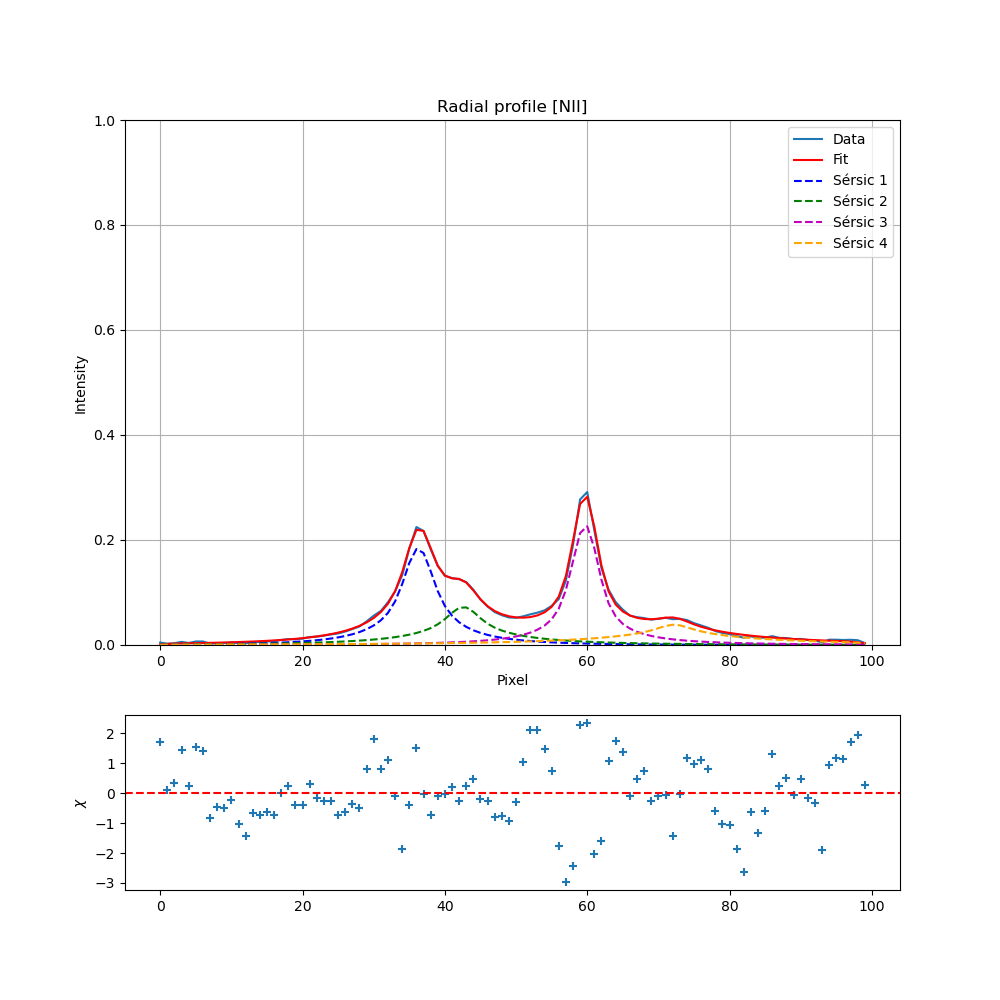

In [71]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_NII)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_NII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_NII[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_NII[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_NII[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_NII[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [NII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)

ax[1].scatter(x_axes, (radial_profile_NII - y_fit)/radial_profile_error_NII, marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

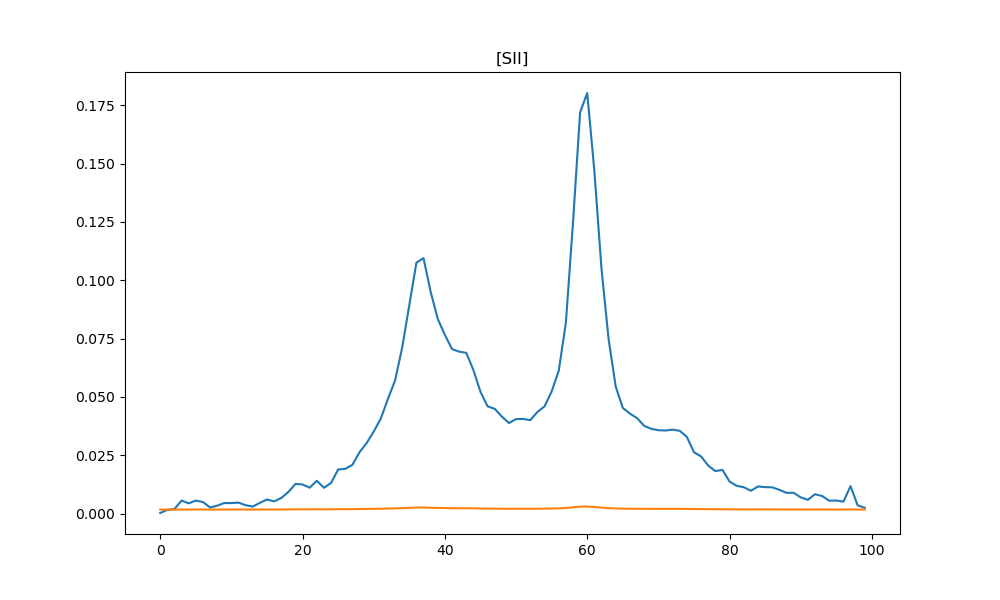

In [78]:
mask_SII = (wavelenghts > l_SII-10)*(wavelenghts < l_SII+10)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.mean(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))/image_error_SII.shape[1]
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [40]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 1.6551392936285336
differential_evolution step 2: f(x)= 0.25522588298081106
differential_evolution step 3: f(x)= 0.25522588298081106
differential_evolution step 4: f(x)= 0.25522588298081106
differential_evolution step 5: f(x)= 0.10138870386269425
differential_evolution step 6: f(x)= 0.08963364861706737
differential_evolution step 7: f(x)= 0.08963364861706737
differential_evolution step 8: f(x)= 0.08963364861706737
differential_evolution step 9: f(x)= 0.08963364861706737
differential_evolution step 10: f(x)= 0.08963364861706737
differential_evolution step 11: f(x)= 0.08963364861706737
differential_evolution step 12: f(x)= 0.08963364861706737
differential_evolution step 13: f(x)= 0.06499261584324212
differential_evolution step 14: f(x)= 0.06499261584324212
differential_evolution step 15: f(x)= 0.06499261584324212
differential_evolution step 16: f(x)= 0.06499261584324212
differential_evolution step 17: f(x)= 0.06499261584324212
differential_evolution s

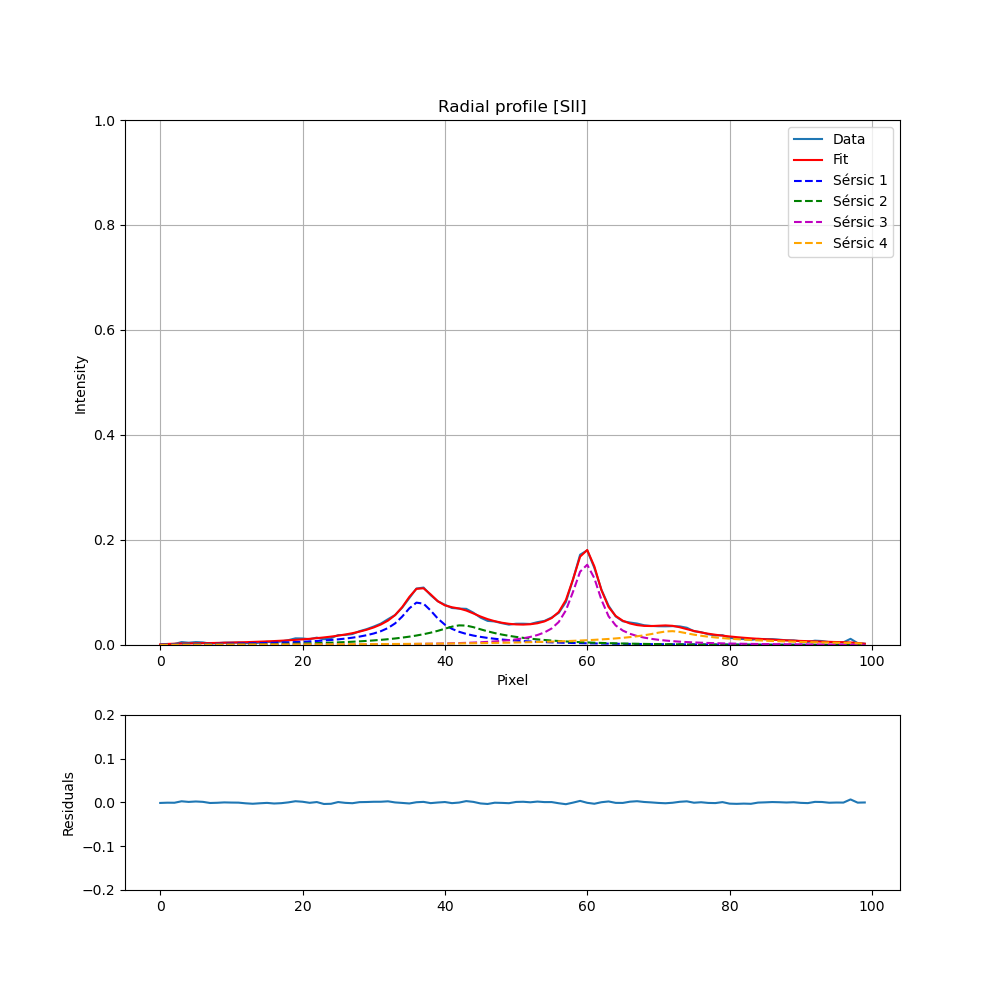

In [41]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_SII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [SII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0,1)

ax[1].plot(x_axes, radial_profile_SII - y_fit)
ax[1].set_ylim(-0.2, 0.2)
ax[1].set_ylabel('Residuals')
plt.savefig('Radial_profile_SII_diff')

In [42]:
params_curve_SII, covariance_SII = curve_fit(model_convolved, x_axes, radial_profile_SII, p0=result.x, sigma = radial_profile_error_SII)

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0 = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_SII[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_SII)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_SII)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_SII)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_SII)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = {'Component': [1, 2, 3, 4], 'I_e': I_e , 'I_e error': I_e_err, 'r_e': r_e, 'r_e error': r_e_err, 'n': n, 'n error': n_err, 'x_0': x_0, 'x_0 err': x_0_err}
df1 = pd.DataFrame(data=d1)
df1.to_csv("SII_fit.csv", index= False, float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_SII)))
#print(infodict.fvec**2)
chi2_SII = np.sum((((radial_profile_SII - model_convolved(x_axes, *params_curve_SII)) / radial_profile_error_SII)**2))
dof_SII = len(radial_profile_SII) - len(params_curve_SII)
chi2_reduced_SII = chi2_SII / dof_SII
print(chi2_reduced_SII)

Sérsic 1: I_e=0.0039, r_e=21.5590, n=2.1110, x_0=36.3752
Sérsic 2: I_e=0.0061, r_e=14.8342, n=1.1689, x_0=42.3012
Sérsic 3: I_e=0.0045, r_e=16.1383, n=2.7625, x_0=59.7614
Sérsic 4: I_e=0.0021, r_e=35.7395, n=1.5467, x_0=71.7778
[2.93576638e-03 1.74067907e+01 4.78458315e-01 1.01285439e-01
 3.95677982e-03 1.39498997e+01 4.43817553e-01 4.58690736e-01
 1.42537685e-02 3.80786035e+01 2.87879067e+00 1.14475941e-02
 1.07451879e-03 1.68027528e+01 2.83428332e-01 3.52784515e-01]
0.9987600454425097


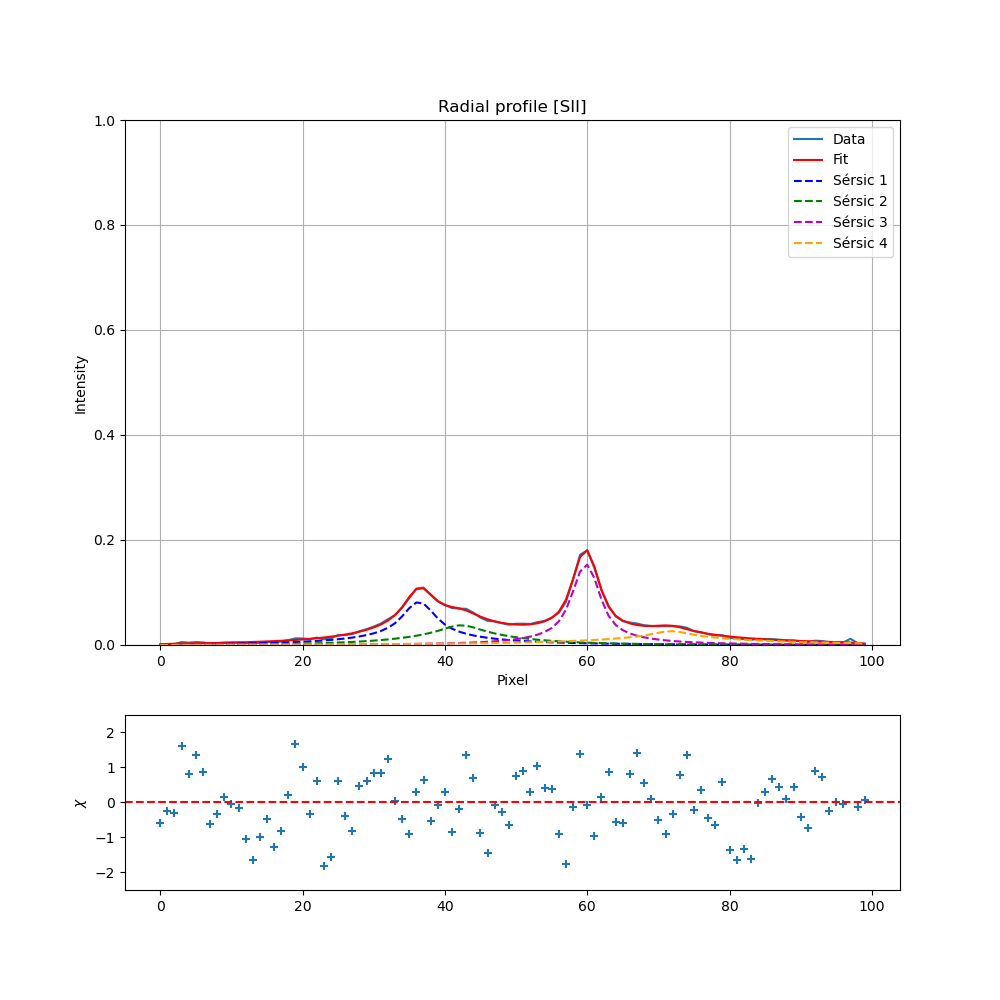

In [81]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_SII)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_SII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_SII[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_SII[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_SII[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_SII[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [SII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)

ax[1].scatter(x_axes, (radial_profile_SII - y_fit)/radial_profile_error_SII,marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')
ax[1].set_ylim(-2.5, 2.5)
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

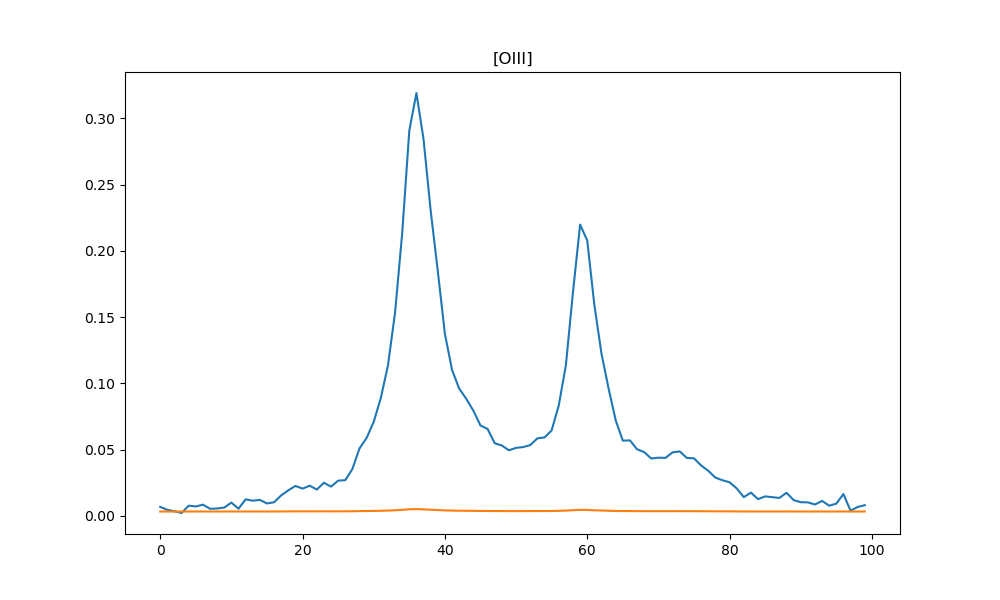

In [79]:
mask_OIII = (wavelenghts > l_OIII-10)*(wavelenghts < l_OIII+10)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.mean(image_OIII, axis = 1) 
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))/image_error_OIII.shape[1]
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [45]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 0.6913246086149334
differential_evolution step 2: f(x)= 0.4449970717927064
differential_evolution step 3: f(x)= 0.1463576858969732
differential_evolution step 4: f(x)= 0.1463576858969732
differential_evolution step 5: f(x)= 0.1463576858969732
differential_evolution step 6: f(x)= 0.1463576858969732
differential_evolution step 7: f(x)= 0.11090891582373938
differential_evolution step 8: f(x)= 0.11090891582373938
differential_evolution step 9: f(x)= 0.11090891582373938
differential_evolution step 10: f(x)= 0.11090891582373938
differential_evolution step 11: f(x)= 0.11090891582373938
differential_evolution step 12: f(x)= 0.11090891582373938
differential_evolution step 13: f(x)= 0.09427490527538106
differential_evolution step 14: f(x)= 0.08530277632999071
differential_evolution step 15: f(x)= 0.08268272867488123
differential_evolution step 16: f(x)= 0.04853663303140472
differential_evolution step 17: f(x)= 0.04853663303140472
differential_evolution step 1

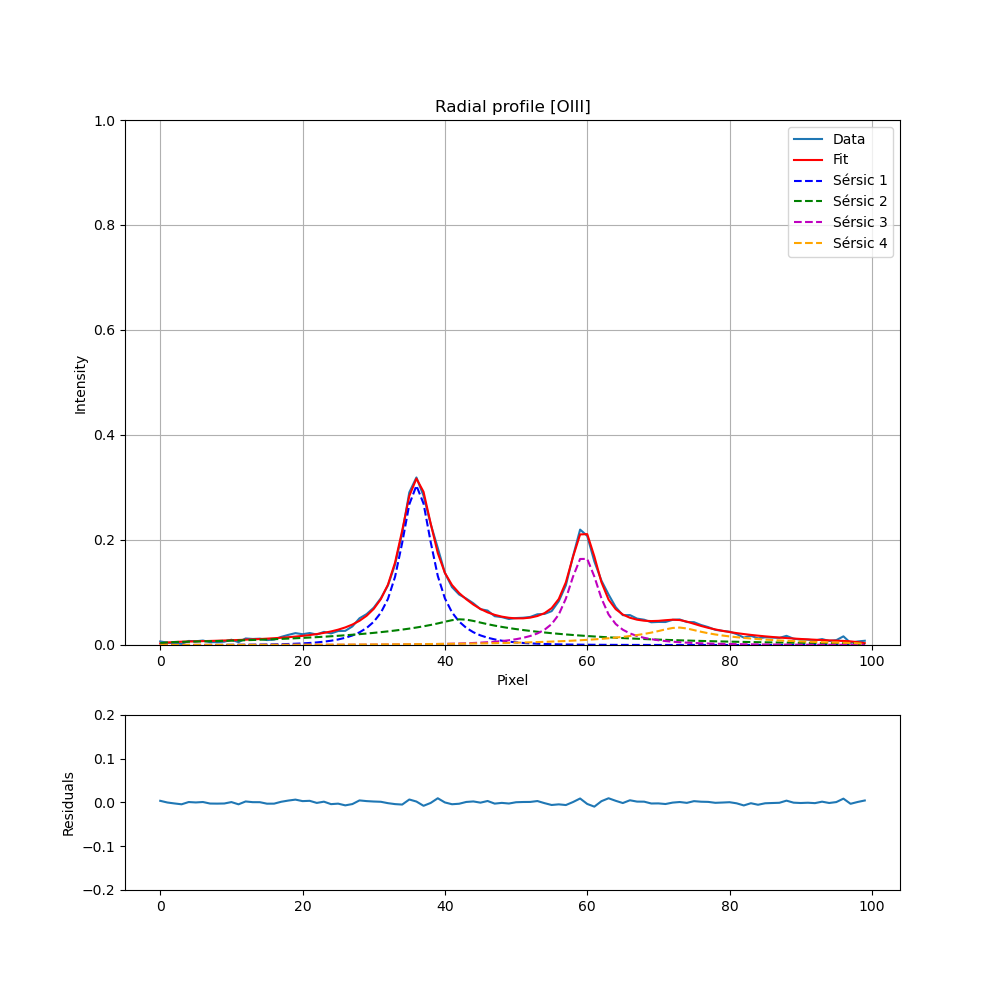

In [46]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_OIII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [OIII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)

ax[1].plot(x_axes, radial_profile_OIII - y_fit)
ax[1].set_ylim(-0.2, 0.2)
ax[1].set_ylabel('Residuals')

plt.savefig('Radial_profile_OIII_kernel')

In [47]:
params_curve_OIII, covariance_OIII = curve_fit(model_convolved, x_axes, radial_profile_OIII, p0=result.x, sigma = radial_profile_error_OIII)

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0 = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_OIII[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_OIII)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_OIII)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_OIII)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_OIII)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = {'Component': [1, 2, 3, 4], 'I_e': I_e , 'I_e error': I_e_err, 'r_e': r_e, 'r_e error': r_e_err, 'n': n, 'n error': n_err, 'x_0': x_0, 'x_0 err': x_0_err}
df1 = pd.DataFrame(data=d1)
df1.to_csv("OIII_fit.csv", index= False, float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_OIII)))
#print(infodict.fvec**2)
chi2_OIII = np.sum((((radial_profile_OIII - model_convolved(x_axes, *params_curve_OIII)) / radial_profile_error_OIII)**2))
dof_OIII = len(radial_profile_OIII) - len(params_curve_OIII)
chi2_reduced_OIII = chi2_OIII / dof_OIII
print(chi2_reduced_OIII)

Sérsic 1: I_e=0.0428, r_e=6.0532, n=1.4167, x_0=36.0389
Sérsic 2: I_e=0.0048, r_e=45.4386, n=1.3462, x_0=42.7331
Sérsic 3: I_e=0.0092, r_e=11.2504, n=2.3242, x_0=59.5139
Sérsic 4: I_e=0.0037, r_e=22.7441, n=1.3557, x_0=72.9943
[7.72516519e-03 1.03547385e+00 1.33261143e-01 4.16047542e-02
 4.66373760e-03 2.83097524e+01 4.48703461e-01 9.02063995e-01
 2.55165311e-02 2.29400431e+01 2.65393733e+00 1.32449240e-02
 2.15978765e-03 1.22904260e+01 3.45827130e-01 5.13474665e-01]
1.0663263155101421


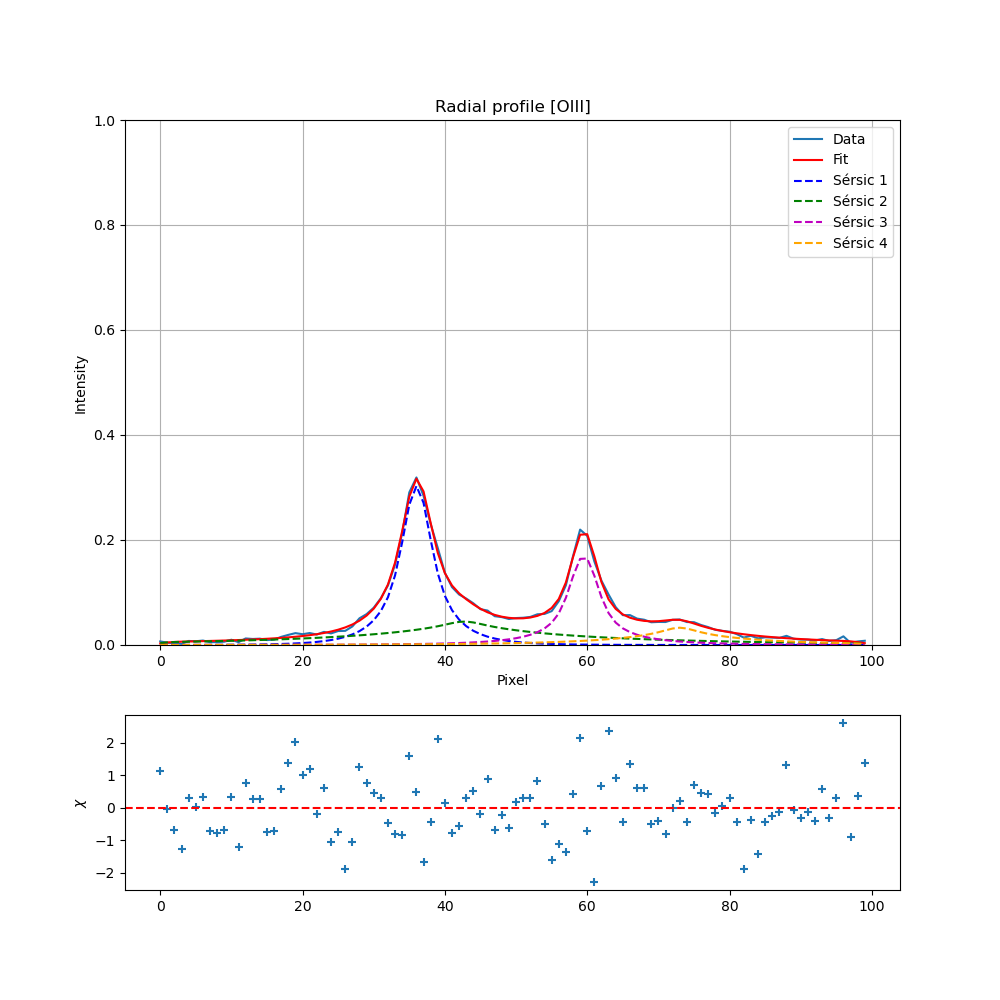

In [73]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_OIII)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_OIII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_OIII[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_OIII[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_OIII[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_OIII[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [OIII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 1)

ax[1].scatter(x_axes, (radial_profile_OIII - y_fit)/radial_profile_error_OIII, marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')
plt.savefig('Radial_profile_OIII_curve')

In [49]:
radial_profile_OIII - y_fit

array([ 3.79585734e-03, -1.06262358e-04, -2.27719300e-03, -4.19643683e-03,
        9.77388566e-04,  8.77617429e-05,  1.09607807e-03, -2.36924283e-03,
       -2.53623557e-03, -2.22320414e-03,  1.06598586e-03, -4.01837725e-03,
        2.52319201e-03,  9.37576271e-04,  9.19790459e-04, -2.47732281e-03,
       -2.36083294e-03,  1.94521779e-03,  4.71543201e-03,  6.88916418e-03,
        3.47269192e-03,  4.11474955e-03, -6.90114705e-04,  2.10879612e-03,
       -3.57026841e-03, -2.53912097e-03, -6.53566445e-03, -3.70696549e-03,
        4.52311399e-03,  2.79069064e-03,  1.75408359e-03,  1.13552485e-03,
       -1.84786932e-03, -3.49922227e-03, -3.79949023e-03,  7.98512371e-03,
        2.48828428e-03, -8.29956189e-03, -1.99845088e-03,  9.32525528e-03,
        5.59213126e-04, -3.06163852e-03, -2.19908522e-03,  1.22036587e-03,
        1.99388614e-03, -7.28620961e-04,  3.32221250e-03, -2.49337491e-03,
       -7.62154226e-04, -2.21018243e-03,  6.59543108e-04,  1.09045832e-03,
        1.13406822e-03,  

In [50]:
radial_profile_error_OIII

array([0.00331341, 0.00329644, 0.00328743, 0.00327892, 0.00331424,
       0.00331559, 0.00332587, 0.00330842, 0.00330945, 0.00330937,
       0.00333465, 0.00330634, 0.00334855, 0.00333322, 0.00333771,
       0.00331717, 0.00333723, 0.0033637 , 0.00339295, 0.00341941,
       0.0034233 , 0.00343978, 0.00341484, 0.00344792, 0.00341958,
       0.00344622, 0.00345198, 0.00350211, 0.00361199, 0.00366071,
       0.00374385, 0.00385843, 0.00400706, 0.00425099, 0.0045621 ,
       0.0049623 , 0.00509094, 0.0049224 , 0.00465412, 0.00440706,
       0.00414566, 0.00399525, 0.00390425, 0.0038574 , 0.00379944,
       0.00371318, 0.00370806, 0.00364025, 0.00364716, 0.00360945,
       0.00361382, 0.00362054, 0.0036277 , 0.00366065, 0.00365857,
       0.0036915 , 0.00380774, 0.00398294, 0.00428759, 0.00454992,
       0.00449773, 0.00423058, 0.0040358 , 0.00387908, 0.00372817,
       0.0036368 , 0.00363632, 0.00359583, 0.00357971, 0.0035422 ,
       0.00354587, 0.00354636, 0.00357765, 0.00357804, 0.00354